In [3]:
from slsne.lcurve import get_all_lcs


In [5]:
# Get light curves of all SLSNe in r-band
band = 'r'
(low, mean, high), (time_samples, lightcurves) = get_all_lcs(band, return_individual=True, sigma=1)

# Get a single light curve
time_samples, r_2018lfe = get_all_lcs(band, names = '2018lfe')



Getting light curves of 241 supernovae in r filter...
1 / 241 1991D
2 / 241 1999as
3 / 241 2002gh
4 / 241 2005ap
5 / 241 2006oz
6 / 241 2007bi
7 / 241 2009cb
8 / 241 2009jh
9 / 241 2010gx
10 / 241 2010hy
11 / 241 2010kd
12 / 241 2010md
13 / 241 2011ke
14 / 241 2011kf
15 / 241 2011kg
16 / 241 2011kl
17 / 241 2012aa
18 / 241 2012il
19 / 241 2013dg
20 / 241 2013hy
21 / 241 2015bn
22 / 241 2016aj
23 / 241 2016ard
24 / 241 2016eay
25 / 241 2016els
26 / 241 2016inl
27 / 241 2016wi
28 / 241 2017dwh
29 / 241 2017egm
30 / 241 2017ens
31 / 241 2017gci
32 / 241 2017hbx
33 / 241 2017jan
34 / 241 2018avk
35 / 241 2018beh
36 / 241 2018bgv
37 / 241 2018bsz
38 / 241 2018bym
39 / 241 2018cxa
40 / 241 2018don
41 / 241 2018fd
42 / 241 2018ffj
43 / 241 2018ffs
44 / 241 2018gbw
45 / 241 2018gft
46 / 241 2018gkz
47 / 241 2018hpq
48 / 241 2018hti
49 / 241 2018ibb
50 / 241 2018kyt
51 / 241 2018lfd
52 / 241 2018lfe
53 / 241 2018lzv
54 / 241 2018lzw
55 / 241 2018lzx
56 / 241 2019aamp
57 / 241 2019aamq
58 / 241

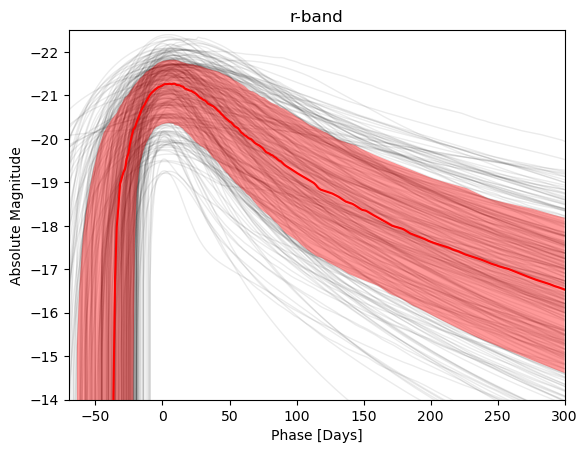

In [7]:
import matplotlib.pyplot as plt
from slsne.utils import plot_colors

# Plot shaded lines for all individual light curves.
plt.plot(time_samples, lightcurves.T, color='k', alpha=0.08, linewidth=1, zorder = 1)

# Plot the mean range in r-band
plt.fill_between(time_samples, low, high, color = plot_colors(band), alpha = 0.4, linewidth = 0, zorder = 2)
plt.plot(time_samples, mean, color = plot_colors(band), zorder = 3)

plt.title(f'{band}-band')
plt.ylabel(f'Absolute Magnitude')
plt.xlabel('Phase [Days]')
plt.ylim(-14, -22.5)
plt.xlim(-70, 300)
plt.show();

In [10]:
from slsne.lcurve import get_kcorr, fit_map
from slsne.utils import get_lc
import numpy as np

In [12]:
# Get a light curve
phot = get_lc('2013dg')
# Define the redshift and date of peak
redshift = 0.265
peak = 56447.62



In [14]:
stretch, amplitude, offset = fit_map(phot, redshift, peak=peak)
print(f"Best fit is a map with Stretch: {stretch:.2f}, Amplitude: {amplitude:.2f}, Offset: {offset:.2f}")


Best fit is a map with Stretch: 1.02, Amplitude: 0.16, Offset: -8.00


In [16]:
K_corr = get_kcorr(phot, redshift, peak=peak, stretch=stretch, offset=offset)


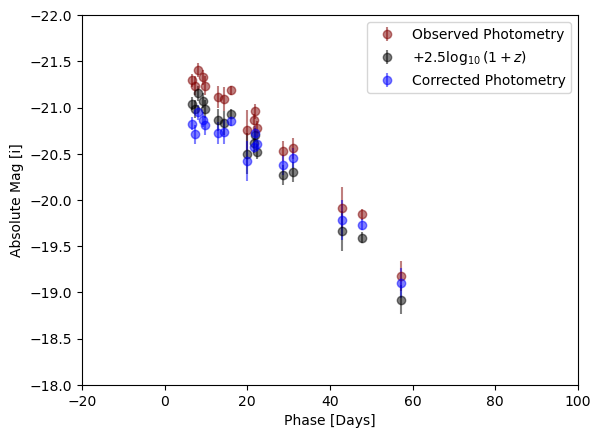

In [18]:
from slsne.utils import calc_DM, plot_colors
import matplotlib.pyplot as plt

# Select band to plot
band = 'i'
use = (phot['Filter'] == band) & (phot['UL'] == 'False')

# Calculate absolute magnitude
DM = calc_DM(redshift)
abs_mag = phot['Mag'][use] - DM

# Calculate Phase
phot['Phase'] = (phot['MJD'] - peak) / (1 + redshift)

# Apply the simple and the optimal K-correction
simple = abs_mag + 2.5 * np.log10(1 + redshift)
optimal = abs_mag - K_corr[use]

# Plot the light curves
plt.errorbar(phot['Phase'][use], abs_mag, yerr = phot['MagErr'][use], fmt = 'o',
             color = plot_colors(band), alpha = 0.5, label = 'Observed Photometry')
plt.errorbar(phot['Phase'][use], simple , yerr = phot['MagErr'][use], fmt = 'o',
             color = 'k', alpha = 0.5, label = r'$+ 2.5 \log_{10}(1 + z)$')
plt.errorbar(phot['Phase'][use], optimal, yerr = phot['MagErr'][use], fmt = 'o',
             color = 'b', alpha = 0.5, label = 'Corrected Photometry')

plt.legend(loc = 'upper right')
plt.ylim(-18, -22)
plt.xlim(-20, 100)
plt.xlabel('Phase [Days]')
plt.ylabel(f'Absolute Mag [{band}]')
plt.show();